In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

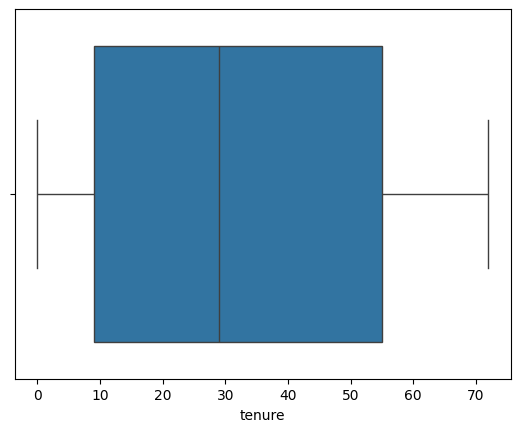

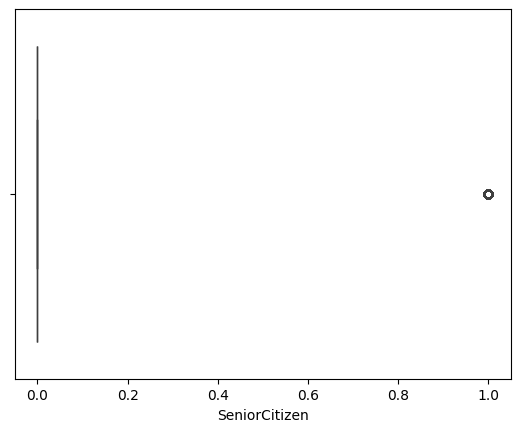

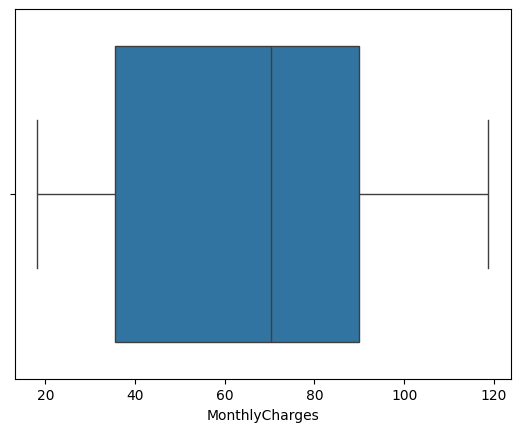

In [8]:
numerical = ["tenure","SeniorCitizen","MonthlyCharges"]
for num in numerical:
    sns.boxplot(data = df, x= num)
    plt.show()

In [9]:
df.drop(columns = ["customerID"],inplace = True)

In [10]:
df.duplicated().sum()

np.int64(22)

In [11]:
df.drop_duplicates(inplace = True)

In [12]:
df.duplicated().sum()

np.int64(0)

# EDA

In [13]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [14]:
df["Churn"].value_counts()

Churn
No     5164
Yes    1857
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

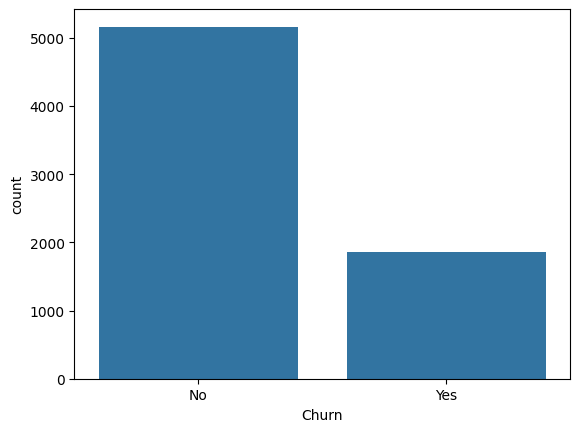

In [15]:
sns.countplot(data = df, x = "Churn")
plt.show

In [16]:
df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [18]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors = "coerce")

In [19]:
df["TotalCharges"].unique()

array([  29.85, 1889.5 ,  108.15, ...,  346.45,  306.6 , 6844.5 ],
      shape=(6531,))

In [20]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [21]:
# as a choice
df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace = True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13184\3364507360.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace = True)


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7021 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7021 non-null   object 
 1   SeniorCitizen     7021 non-null   int64  
 2   Partner           7021 non-null   object 
 3   Dependents        7021 non-null   object 
 4   tenure            7021 non-null   int64  
 5   PhoneService      7021 non-null   object 
 6   MultipleLines     7021 non-null   object 
 7   InternetService   7021 non-null   object 
 8   OnlineSecurity    7021 non-null   object 
 9   OnlineBackup      7021 non-null   object 
 10  DeviceProtection  7021 non-null   object 
 11  TechSupport       7021 non-null   object 
 12  StreamingTV       7021 non-null   object 
 13  StreamingMovies   7021 non-null   object 
 14  Contract          7021 non-null   object 
 15  PaperlessBilling  7021 non-null   object 
 16  PaymentMethod     7021 non-null   object 
 17  

<function matplotlib.pyplot.show(close=None, block=None)>

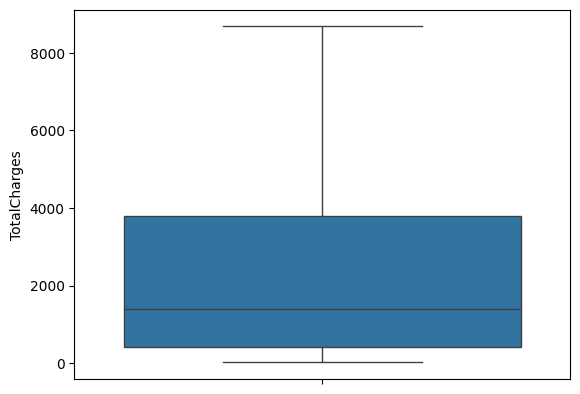

In [23]:
sns.boxplot(df["TotalCharges"])
plt.show

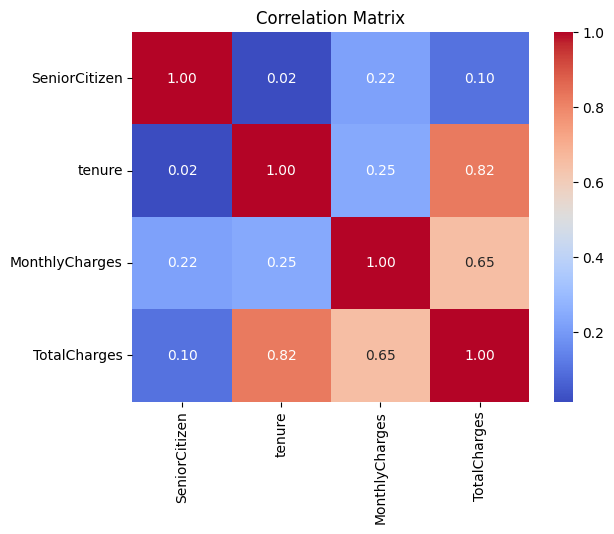

In [24]:
corr = df.corr(numeric_only = True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

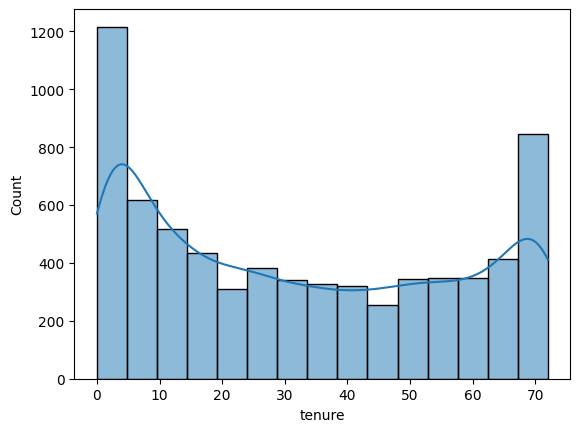

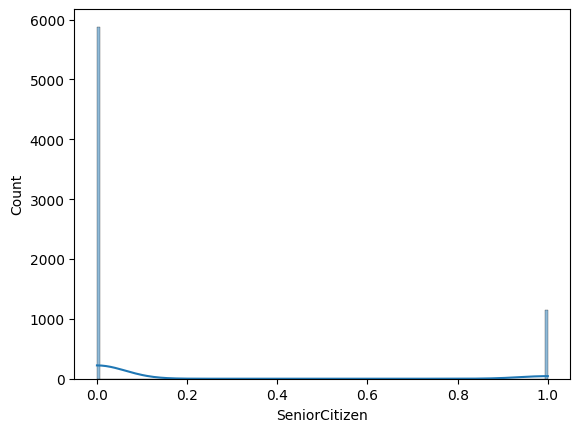

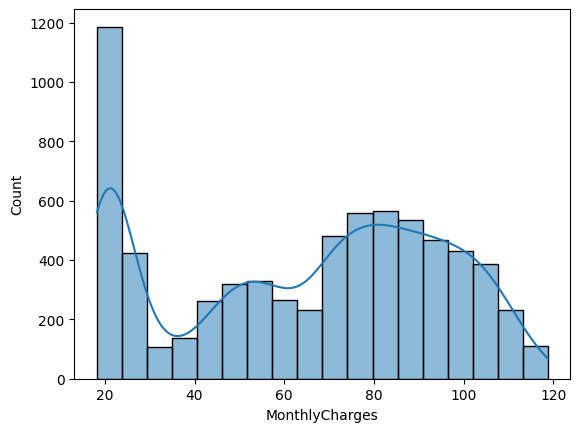

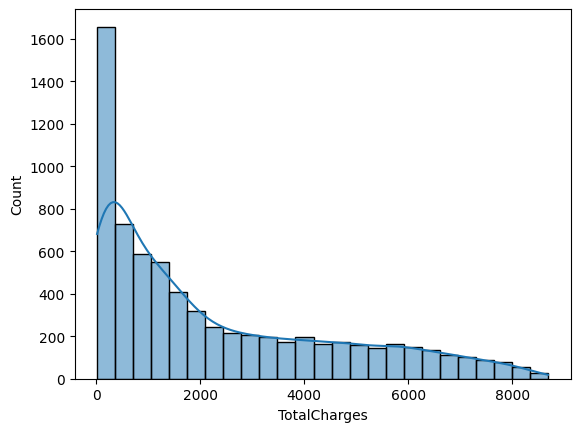

In [25]:
numericals = ["tenure", "SeniorCitizen", "MonthlyCharges", "TotalCharges"]
for num in numericals:
    sns.histplot(df[num], kde = True)
    plt.show()

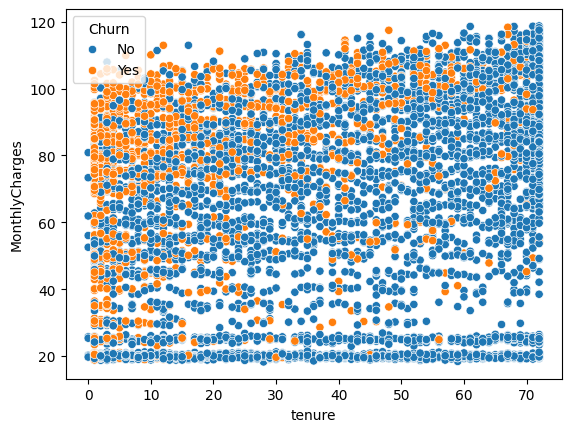

In [26]:
sns.scatterplot(data = df, x='tenure', y = 'MonthlyCharges', hue= 'Churn')
plt.show()

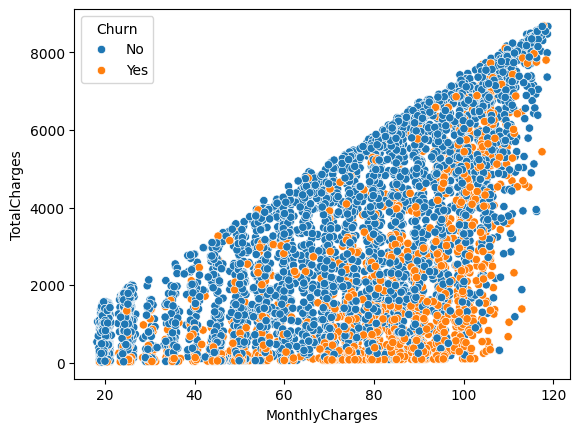

In [27]:
sns.scatterplot(data=df, x = 'MonthlyCharges', y= 'TotalCharges', hue='Churn')
plt.show()

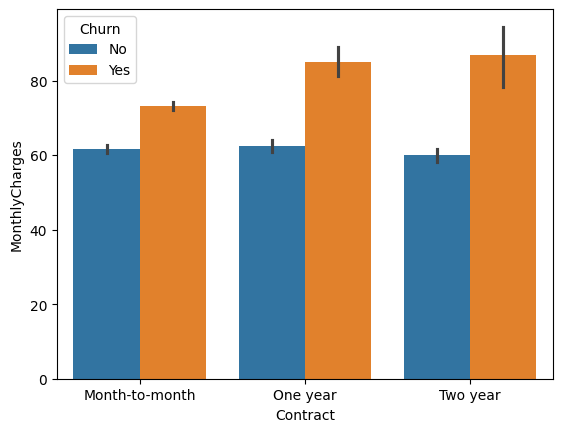

In [28]:
sns.barplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn')
plt.show()

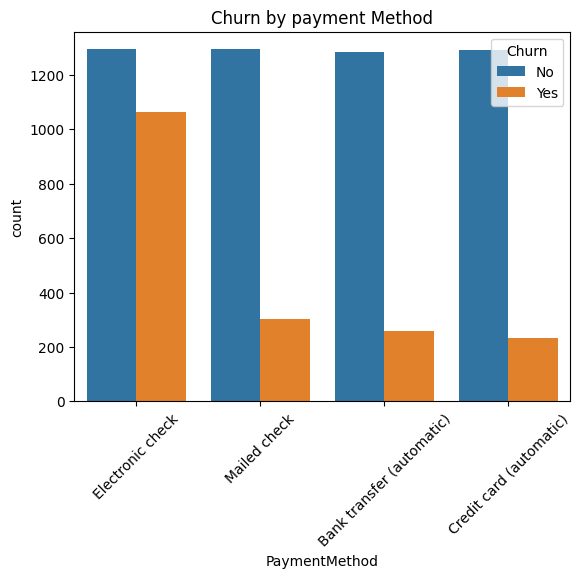

In [29]:
sns.countplot(data= df, x='PaymentMethod', hue='Churn')
plt.xticks(rotation=45)
plt.title("Churn by payment Method")
plt.show()

In [30]:
for col in df.select_dtypes(include = "object"):
    print(df[col].value_counts())
    print("---------------------------------------------------------------")

gender
Male      3541
Female    3480
Name: count, dtype: int64
---------------------------------------------------------------
Partner
No     3619
Yes    3402
Name: count, dtype: int64
---------------------------------------------------------------
Dependents
No     4911
Yes    2110
Name: count, dtype: int64
---------------------------------------------------------------
PhoneService
Yes    6339
No      682
Name: count, dtype: int64
---------------------------------------------------------------
MultipleLines
No                  3368
Yes                 2971
No phone service     682
Name: count, dtype: int64
---------------------------------------------------------------
InternetService
Fiber optic    3090
DSL            2419
No             1512
Name: count, dtype: int64
---------------------------------------------------------------
OnlineSecurity
No                     3490
Yes                    2019
No internet service    1512
Name: count, dtype: int64
-----------------------------

In [33]:
for col in df.select_dtypes(include = "object"):
    count = pd.crosstab(df[col] , df["Churn"],normalize = 'index')
    print(count)
    print("---------------------------------------------------")
    

Churn         No       Yes
gender                    
Female  0.731609  0.268391
Male    0.739339  0.260661
---------------------------------------------------
Churn          No       Yes
Partner                    
No       0.671733  0.328267
Yes      0.803351  0.196649
---------------------------------------------------
Churn             No       Yes
Dependents                    
No          0.688251  0.311749
Yes         0.845498  0.154502
---------------------------------------------------
Churn               No       Yes
PhoneService                    
No            0.750733  0.249267
Yes           0.733870  0.266130
---------------------------------------------------
Churn                   No       Yes
MultipleLines                       
No                0.751485  0.248515
No phone service  0.750733  0.249267
Yes               0.713901  0.286099
---------------------------------------------------
Churn                  No       Yes
InternetService                    
DSL    

# EDA Insights